# Thermal Comfort Classification — Data Analysis & EDA
**Project:** Understanding classroom thermal comfort using deep learning  
**Dataset:** ASHRAE Global Thermal Comfort Database II  

## Objective
Predict thermal sensation votes (TSV) from environmental and personal parameters
using machine learning. TSV ranges from -3 (cold) to +3 (hot) on the ASHRAE 7-point scale.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import warnings
import os

warnings.filterwarnings('ignore')

# Set consistent plot style for all figures
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

DATA_DIR = Path('../data')
DATA_DIR.mkdir(exist_ok=True)

print("✓ Imports successful")
print(f"  numpy {np.__version__}  |  pandas {pd.__version__}")

✓ Imports successful
  numpy 2.1.3  |  pandas 2.2.3


Download the ASHRAE dataset from Kaggle

In [2]:

# BEFORE running this cell:
#   1. Go to https://www.kaggle.com/settings/account
#   2. Scroll to "API" → click "Create New Token"
#   3. A file called kaggle.json downloads
#   4. Move it to:
#        Windows: C:\Users\<YourName>\.kaggle\kaggle.json
#        Mac/Linux: ~/.kaggle/kaggle.json
# =============================================================================

import subprocess, sys

DATASET_PATH = DATA_DIR / 'ashrae_db2.csv'

if not DATASET_PATH.exists():
    print("Downloading ASHRAE dataset from Kaggle...")
    result = subprocess.run(
        ['kaggle', 'datasets', 'download',
         '-d', 'claytonmiller/ashrae-global-thermal-comfort-database-ii',
         '--unzip', '-p', str(DATA_DIR)],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("Kaggle download failed. Trying manual fallback...")
        print(result.stderr)
        print("\nManual option: Download the CSV from:")
        print("https://www.kaggle.com/datasets/claytonmiller/ashrae-global-thermal-comfort-database-ii")
        print(f"Then place it in: {DATA_DIR.resolve()}")
    else:
        print("✓ Download complete")
        # Find whatever CSV was downloaded
        csvs = list(DATA_DIR.glob('*.csv'))
        print(f"  Found: {[f.name for f in csvs]}")
else:
    print(f"✓ Dataset already present at {DATASET_PATH}")

✓ Download complete
  Found: ['ashrae_db2.01.csv']


In [3]:
# =============================================================================
# CELL 4: Load the data and get a first look
# =============================================================================

# Find the CSV (name may vary after unzip)
csv_files = list(DATA_DIR.glob('*.csv'))
if not csv_files:
    raise FileNotFoundError(
        f"No CSV found in {DATA_DIR}. "
        "Please download and place the ASHRAE CSV there manually."
    )

# Load whichever CSV we found
df_raw = pd.read_csv(csv_files[0], low_memory=False)
print(f"✓ Loaded: {csv_files[0].name}")
print(f"  Shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

# Show first rows
print("\n--- First 3 rows ---")
df_raw.head(3)

✓ Loaded: ashrae_db2.01.csv
  Shape  : 107,583 rows × 70 columns

--- First 3 rows ---


,Publication (Citation),Data contributor,Year,Season,Koppen climate classification,Climate,City,Country,Building type,Cooling startegy_building level,...,Subject«s height (cm),Subject«s weight (kg),Blind (curtain),Fan,Window,Door,Heater,Outdoor monthly air temperature (C),Outdoor monthly air temperature (F),Database
0,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,162.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2
1,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,154.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2
2,"Kwok, Alison G., and Chungyoon Chun. ""Thermal ...",Kwok Alison,2000.0,Summer,Cfa,Humid subtropical,Tokyo,Japan,Classroom,Air Conditioned,...,173.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,77.0,Database 2


In [4]:
# =============================================================================
# CELL 5: Select relevant columns and clean the data
#
# The ASHRAE DB-II has 100+ columns. We keep the ones most important
# for thermal comfort prediction based on established literature (ASHRAE 55).
# =============================================================================

# These are the standard thermal comfort predictors from ASHRAE 55 standard
# plus occupant characteristics
FEATURE_COLS = [
    # Environmental parameters
    'Air temperature (C)',
    'Radiant temperature (C)',
    'Relative humidity (%)',
    'Air velocity (m/s)',
    # Personal parameters
    'Clothing level',          # CLO value — insulation of clothing
    'Metabolic rate',          # MET value — activity level
    # Building context
    'Building type',
    'Climate',
    'Season',
]

TARGET_COL = 'Thermal sensation'   # TSV: -3 (cold) to +3 (hot)

# Keep only columns that exist in this version of the dataset
# (column names sometimes differ slightly between versions)
available = df_raw.columns.tolist()

def find_col(candidates, available):
    """Find best matching column name (case-insensitive partial match)."""
    for c in candidates:
        for a in available:
            if c.lower() in a.lower():
                return a
    return None

col_map = {}
search = {
    'air_temp':    ['Air temperature', 'Ta', 'air temp'],
    'radiant':     ['Radiant temperature', 'Tr', 'radiant'],
    'humidity':    ['Relative humidity', 'RH', 'humidity'],
    'velocity':    ['Air velocity', 'Va', 'air velocity'],
    'clothing':    ['Clothing', 'clo'],
    'metabolic':   ['Metabolic', 'met'],
    'building':    ['Building type', 'building'],
    'climate':     ['Climate', 'Koppen'],
    'season':      ['Season'],
    'tsv':         ['Thermal sensation', 'TSV', 'thermal sensation'],
}

print("Column matching:")
for key, candidates in search.items():
    matched = find_col(candidates, available)
    col_map[key] = matched
    status = "✓" if matched else "✗ NOT FOUND"
    print(f"  {key:12s} → {matched or 'MISSING':40s} {status}")

# Build working dataframe with renamed columns
rename = {v: k for k, v in col_map.items() if v is not None}
df = df_raw[list(rename.keys())].rename(columns=rename).copy()

print(f"\n✓ Working dataframe shape: {df.shape}")
df.head(3)

Column matching:
  air_temp     → Air temperature (C)                      ✓
  radiant      → Radiant temperature (C)                  ✓
  humidity     → Relative humidity (%)                    ✓
  velocity     → Air velocity (m/s)                       ✓
  clothing     → Clo                                      ✓
  metabolic    → Met                                      ✓
  building     → Building type                            ✓
  climate      → Koppen climate classification            ✓
  season       → Season                                   ✓
  tsv          → Thermal sensation                        ✓

✓ Working dataframe shape: (107583, 10)


,air_temp,radiant,humidity,velocity,clothing,metabolic,building,climate,season,tsv
0,24.2,NaN,50.2,0.06,0.25,NaN,Classroom,Cfa,Summer,-0.5
1,24.2,NaN,50.2,0.06,0.25,NaN,Classroom,Cfa,Summer,-2.1
2,24.2,NaN,50.2,0.06,0.27,NaN,Classroom,Cfa,Summer,0.5


In [5]:
# =============================================================================
# CELL 6: Missing values analysis and target distribution
# =============================================================================

print("=== Missing values ===")
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(1)
miss_df = pd.DataFrame({'missing': missing, 'pct': pct})
print(miss_df[miss_df['missing'] > 0].to_string())

# Drop rows where target is missing — we cannot train without labels
df = df.dropna(subset=['tsv'])
print(f"\nAfter dropping missing TSV: {len(df):,} rows")

# Round TSV to integer (some entries are floats like 1.0 → 1)
df['tsv'] = df['tsv'].round().astype(int)

# Show class distribution
print("\n=== TSV class distribution ===")
counts = df['tsv'].value_counts().sort_index()
labels = {-3:'Cold', -2:'Cool', -1:'Slightly cool',
           0:'Neutral', 1:'Slightly warm', 2:'Warm', 3:'Hot'}
for v, c in counts.items():
    bar = '█' * int(c / counts.max() * 30)
    print(f"  {v:+d} ({labels.get(v,'?'):15s}): {c:6,}  {bar}")

=== Missing values ===
           missing   pct
air_temp      7672   7.1
radiant      75110  69.8
humidity      9821   9.1
velocity     17691  16.4
clothing      7920   7.4
metabolic    17164  16.0
building      4199   3.9
season         241   0.2
tsv           3129   2.9

After dropping missing TSV: 104,454 rows

=== TSV class distribution ===
  -3 (Cold           ):  2,350  █
  -2 (Cool           ):  6,349  ████
  -1 (Slightly cool  ): 16,753  ███████████
  +0 (Neutral        ): 44,063  ██████████████████████████████
  +1 (Slightly warm  ): 20,086  █████████████
  +2 (Warm           ): 10,542  ███████
  +3 (Hot            ):  4,311  ██


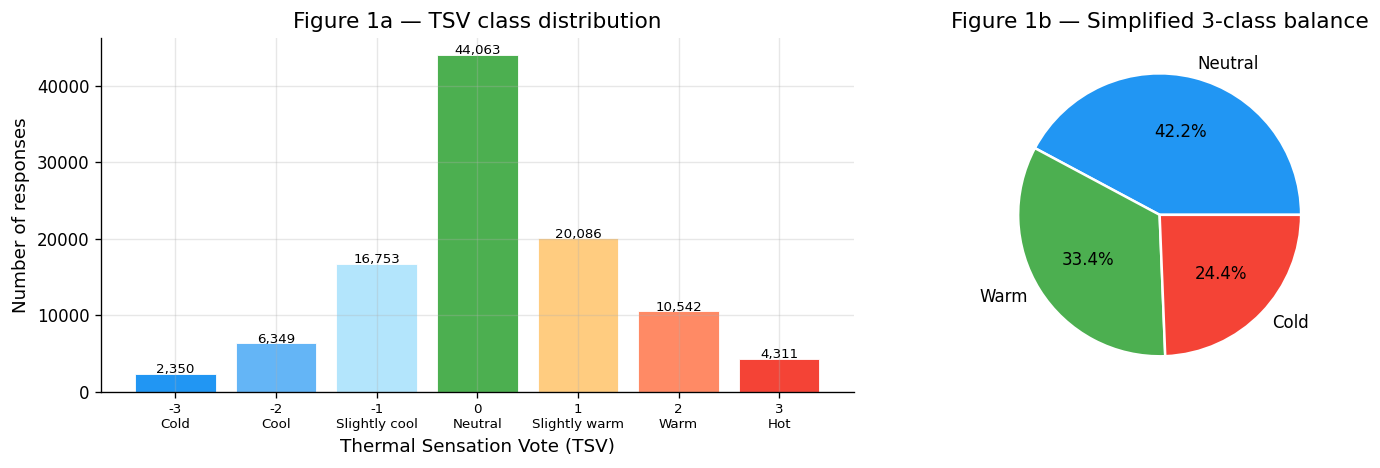

✓ Saved fig1_tsv_distribution.png


In [6]:
# =============================================================================
# CELL 7: Figure 1 — TSV distribution bar chart
# This is the key visualisation showing class imbalance
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: absolute counts
colors_tsv = ['#2196F3','#64B5F6','#B3E5FC','#4CAF50','#FFCC80','#FF8A65','#F44336']
counts_sorted = df['tsv'].value_counts().sort_index()
bars = axes[0].bar(counts_sorted.index, counts_sorted.values,
                   color=colors_tsv[:len(counts_sorted)], edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Thermal Sensation Vote (TSV)')
axes[0].set_ylabel('Number of responses')
axes[0].set_title('Figure 1a — TSV class distribution')
axes[0].set_xticks(counts_sorted.index)
axes[0].set_xticklabels([f"{v}\n{labels.get(v,'')}" for v in counts_sorted.index], fontsize=8)
for bar, val in zip(bars, counts_sorted.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=8)

# Right: pie of simplified 3-class (cold / neutral / warm)
df['tsv3'] = df['tsv'].map(
    {-3:'Cold',-2:'Cold',-1:'Cold', 0:'Neutral', 1:'Warm', 2:'Warm', 3:'Warm'})
pie_data = df['tsv3'].value_counts()
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            colors=['#2196F3','#4CAF50','#F44336'],
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Figure 1b — Simplified 3-class balance')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_tsv_distribution.png', bbox_inches='tight')
plt.show()
print("✓ Saved fig1_tsv_distribution.png")

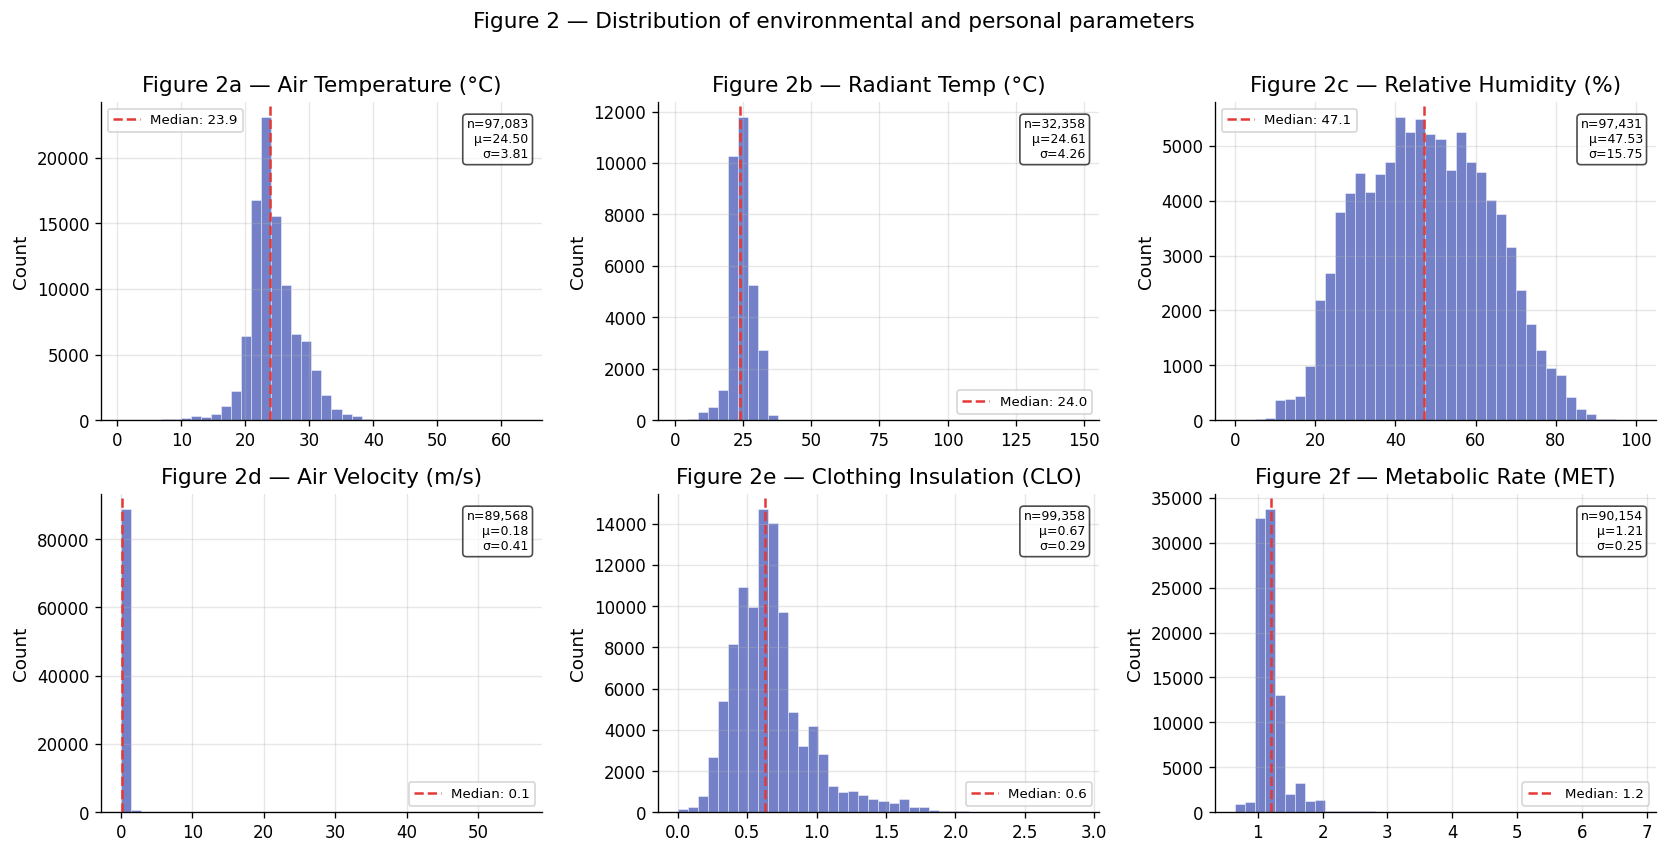

✓ Saved fig2_feature_distributions.png


In [7]:
# =============================================================================
# CELL 8: Figure 2 — Distributions of all numerical features
# This helps understand the data range and spot outliers
# =============================================================================

num_cols = ['air_temp','radiant','humidity','velocity','clothing','metabolic']
existing_num = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

col_labels = {
    'air_temp':  'Air Temperature (°C)',
    'radiant':   'Radiant Temp (°C)',
    'humidity':  'Relative Humidity (%)',
    'velocity':  'Air Velocity (m/s)',
    'clothing':  'Clothing Insulation (CLO)',
    'metabolic': 'Metabolic Rate (MET)',
}

for i, col in enumerate(existing_num):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=40, color='#5C6BC0', edgecolor='white', linewidth=0.3, alpha=0.85)
    ax.axvline(data.median(), color='#E53935', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.1f}')
    ax.set_title(f'Figure 2{chr(97+i)} — {col_labels.get(col, col)}')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    # Annotate with basic stats
    ax.text(0.97, 0.95, f'n={len(data):,}\nμ={data.mean():.2f}\nσ={data.std():.2f}',
            transform=ax.transAxes, va='top', ha='right', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.suptitle('Figure 2 — Distribution of environmental and personal parameters',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_feature_distributions.png', bbox_inches='tight')
plt.show()
print("✓ Saved fig2_feature_distributions.png")

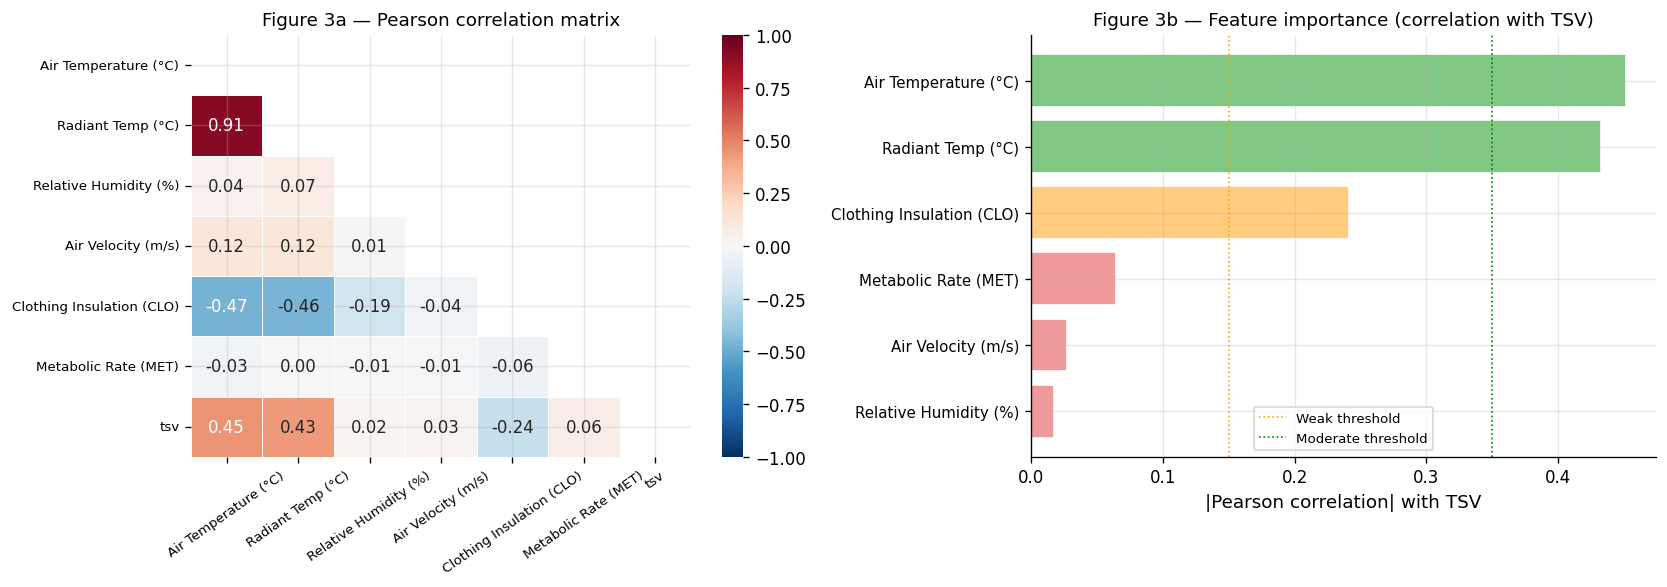

✓ Saved fig3_correlations.png


In [8]:
# =============================================================================
# CELL 9: Figure 3 — Correlation heatmap
# Shows which features are most related to TSV
# This is a critical analysis for the report's requirement section
# =============================================================================

num_df = df[existing_num + ['tsv']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full correlation matrix
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            xticklabels=[col_labels.get(c,c) for c in corr.columns],
            yticklabels=[col_labels.get(c,c) for c in corr.index])
axes[0].set_title('Figure 3a — Pearson correlation matrix', fontsize=11)
axes[0].tick_params(axis='x', rotation=35, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# Bar chart of correlation with TSV only
tsv_corr = corr['tsv'].drop('tsv').abs().sort_values(ascending=True)
colors_bar = ['#EF9A9A' if tsv_corr[c] < 0.15 else
              '#FFCC80' if tsv_corr[c] < 0.35 else '#81C784'
              for c in tsv_corr.index]
axes[1].barh(range(len(tsv_corr)), tsv_corr.values, color=colors_bar,
             edgecolor='white')
axes[1].set_yticks(range(len(tsv_corr)))
axes[1].set_yticklabels([col_labels.get(c,c) for c in tsv_corr.index], fontsize=9)
axes[1].set_xlabel('|Pearson correlation| with TSV')
axes[1].set_title('Figure 3b — Feature importance (correlation with TSV)', fontsize=11)
axes[1].axvline(0.15, color='orange', linestyle=':', linewidth=1, label='Weak threshold')
axes[1].axvline(0.35, color='green', linestyle=':', linewidth=1, label='Moderate threshold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_correlations.png', bbox_inches='tight')
plt.show()
print("✓ Saved fig3_correlations.png")

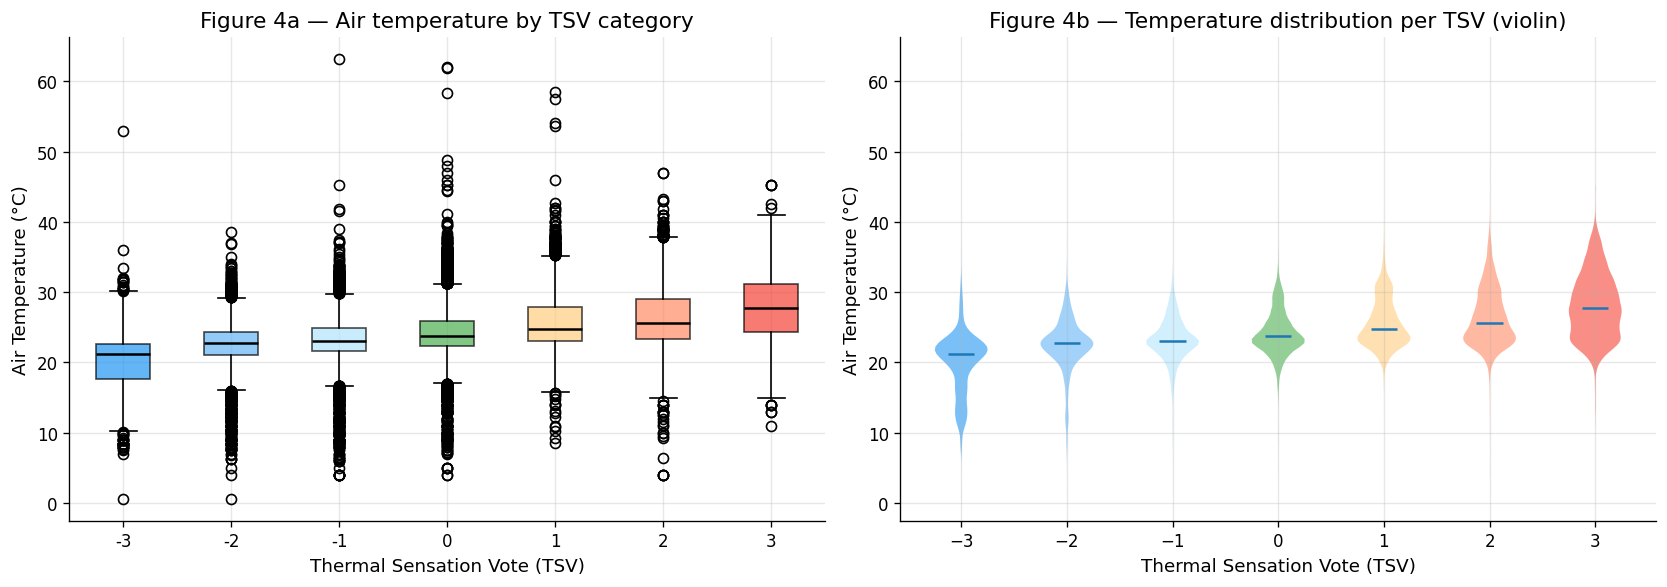

✓ Saved fig4_temp_vs_tsv.png


In [9]:
# =============================================================================
# CELL 10: Figure 4 — TSV vs air temperature box plots
# This is the most intuitive visualisation: do hotter rooms = higher TSV?
# =============================================================================

if 'air_temp' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Boxplot: air temp by TSV category
    tsv_groups = [df[df['tsv'] == v]['air_temp'].dropna().values
                  for v in sorted(df['tsv'].unique())]
    bp = axes[0].boxplot(tsv_groups, patch_artist=True,
                         labels=[str(v) for v in sorted(df['tsv'].unique())],
                         medianprops={'color':'black','linewidth':1.5})
    for patch, color in zip(bp['boxes'], colors_tsv):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[0].set_xlabel('Thermal Sensation Vote (TSV)')
    axes[0].set_ylabel('Air Temperature (°C)')
    axes[0].set_title('Figure 4a — Air temperature by TSV category')

    # Violin plot for richer view
    plot_df = df[['tsv','air_temp']].dropna()
    plot_df = plot_df[plot_df['tsv'].between(-3,3)]
    parts = axes[1].violinplot(
        [plot_df[plot_df['tsv']==v]['air_temp'].values
         for v in sorted(plot_df['tsv'].unique())],
        positions=sorted(plot_df['tsv'].unique()),
        showmedians=True, showextrema=False
    )
    for pc, color in zip(parts['bodies'], colors_tsv):
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
    axes[1].set_xlabel('Thermal Sensation Vote (TSV)')
    axes[1].set_ylabel('Air Temperature (°C)')
    axes[1].set_title('Figure 4b — Temperature distribution per TSV (violin)')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig4_temp_vs_tsv.png', bbox_inches='tight')
    plt.show()
    print("✓ Saved fig4_temp_vs_tsv.png")

## Requirements Analysis

### Problem Scope
Thermal comfort affects student learning outcomes, energy efficiency, and wellbeing.
Standard models (PMV — Predicted Mean Vote, Fanger 1970) rely on 6 inputs
but assume steady-state conditions. Real classroom data is messier.

### Project Requirements (from rubric + project owner)
| ID  | Requirement |
|-----|-------------|
| R1  | System shall classify TSV into 7 categories (-3 to +3) |
| R2  | System shall accept environmental inputs: Ta, Tr, RH, Va |
| R3  | System shall accept personal inputs: CLO, MET |
| R4  | System shall achieve ≥ 60% weighted F1-score (baseline PMV achieves ~55%) |
| R5  | System shall handle missing values in input features |
| R6  | Model training shall complete within 10 minutes on a standard laptop |
| R7  | System shall produce interpretable feature importance output |

### Literature Context
- Fanger (1970): PMV model — physics-based, 6 inputs, steady state assumption
- De Dear & Brager (1998): Adaptive comfort model — people adapt to climate
- Cheung et al. (2019): ASHRAE DB-II analysis shows PMV overpredicts discomfort
- Zhang et al. (2021): ML outperforms PMV at 3-class classification (F1 ~0.72)

In [10]:
# =============================================================================
# CELL 12: Save cleaned dataset for use in later notebooks
# =============================================================================

save_path = DATA_DIR / 'ashrae_cleaned.csv'
df.to_csv(save_path, index=False)
print(f"✓ Cleaned data saved to {save_path}")
print(f"  Shape: {df.shape}")
print(f"  Columns: {df.columns.tolist()}")
print(f"\nReady for notebook 02!")

✓ Cleaned data saved to ..\data\ashrae_cleaned.csv
  Shape: (104454, 11)
  Columns: ['air_temp', 'radiant', 'humidity', 'velocity', 'clothing', 'metabolic', 'building', 'climate', 'season', 'tsv', 'tsv3']

Ready for notebook 02!
